<a href="https://colab.research.google.com/github/aramrdz06/Nuevo-Leon-Accident-Analysis-Dashboard/blob/main/actividad_1_de_algoritmo_de_aprendizaje_autom%C3%A1tico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

diccionario_datos = pd.DataFrame({
    "No.": list(range(1, 12)),
    "Variable": [
        "id_solicitud", "edad", "ingreso_mensual", "antiguedad_laboral",
        "historial_crediticio", "creditos_activos", "utilizacion_credito",
        "pagos_atrasados", "monto_solicitado", "plazo_meses", "riesgo"
    ],
    "Descripción": [
        "Identificador único de la solicitud de crédito",
        "Edad del cliente solicitante, en años",
        "Ingreso mensual del cliente, en pesos",
        "Años de antigüedad del cliente en su empleo actual",
        "Puntaje de historial crediticio del cliente (tipo buró de crédito)",
        "Número de créditos que el cliente tiene actualmente activos",
        "Porcentaje de la línea de crédito disponible que el cliente utiliza actualmente",
        "Número de pagos que el cliente ha realizado con atraso",
        "Monto de dinero solicitado en el crédito, en pesos",
        "Plazo del crédito solicitado, expresado en meses",
        "Resultado observado de la solicitud: 0 = Bajo riesgo, 1 = Alto riesgo"
    ],
    "Tipo de dato": [
        "Texto (str)", "Numérico (entero)", "Numérico (entero)", "Numérico (decimal)",
        "Numérico (entero)", "Numérico (entero)", "Numérico (decimal, %)",
        "Numérico (decimal)", "Numérico (entero)", "Numérico (entero)",
        "Numérico (entero, categórico)"
    ],
    "Rol en el modelo": [
        "Identificador", "Entrada (X)", "Entrada (X)", "Entrada (X)",
        "Entrada (X)", "Entrada (X)", "Entrada (X)",
        "Entrada (X)", "Entrada (X)", "Entrada (X)",
        "Salida (Y) — variable objetivo"
    ]
})

diccionario_datos.set_index("No.")

,Variable,Descripción,Tipo de dato,Rol en el modelo
No.,,,,
1,id_solicitud,Identificador único de la solicitud de crédito,Texto (str),Identificador
2,edad,"Edad del cliente solicitante, en años",Numérico (entero),Entrada (X)
3,ingreso_mensual,"Ingreso mensual del cliente, en pesos",Numérico (entero),Entrada (X)
4,antiguedad_laboral,Años de antigüedad del cliente en su empleo ac...,Numérico (decimal),Entrada (X)
5,historial_crediticio,Puntaje de historial crediticio del cliente (t...,Numérico (entero),Entrada (X)
6,creditos_activos,Número de créditos que el cliente tiene actual...,Numérico (entero),Entrada (X)
7,utilizacion_credito,Porcentaje de la línea de crédito disponible q...,"Numérico (decimal, %)",Entrada (X)
8,pagos_atrasados,Número de pagos que el cliente ha realizado co...,Numérico (decimal),Entrada (X)
9,monto_solicitado,"Monto de dinero solicitado en el crédito, en p...",Numérico (entero),Entrada (X)


In [ ]:
import pandas as pd

# dataset
df = pd.read_csv('solicitudes_credito_500.csv')

# 2. Visualizar los primeros registros en forma de tabla interactiva
print("--- PASO 1: Primeros registros del dataset ---")
display(df.head())

--- PASO 1: Primeros registros del dataset ---


,id_solicitud,edad,ingreso_mensual,antiguedad_laboral,historial_crediticio,creditos_activos,utilizacion_credito,pagos_atrasados,monto_solicitado,plazo_meses,riesgo
0,CR-0001,59,31311,5.2,739,3,51.1,0.0,22209,24,0
1,CR-0002,49,10068,4.0,723,2,44.1,2.0,3000,48,0
2,CR-0003,35,36237,9.9,755,4,45.5,0.0,32517,24,0
3,CR-0004,63,11575,12.1,633,4,13.6,0.0,3141,48,1
4,CR-0005,28,10311,14.0,706,1,56.3,1.0,3858,36,0


In [ ]:
#3.1
import pandas as pd

tabla_reglas = pd.DataFrame({
    "Regla": ["R1", "R2", "R3", "R4", "R5"],
    "Variable": [
        "historial_crediticio",
        "utilizacion_credito",
        "pagos_atrasados",
        "antiguedad_laboral",
        "monto_solicitado, ingreso_mensual, plazo_meses"
    ],
    "Condición": [
        "historial_crediticio < 650",
        "utilizacion_credito > 50%",
        "pagos_atrasados >= 2",
        "antiguedad_laboral < 2 años",
        "monto_solicitado > 0.6 × (ingreso_mensual × plazo_meses / 12)"
    ],
    "Resultado": [
        "+1 punto de riesgo",
        "+1 punto de riesgo",
        "+1 punto de riesgo",
        "+1 punto de riesgo",
        "+1 punto de riesgo"
    ],
    "Justificación": [
        "Un historial crediticio bajo indica antecedentes de mal manejo del crédito; es, por sí solo, uno de los mejores predictores de incumplimiento.",
        "Un cliente que ya está usando más de la mitad de su línea de crédito disponible tiene menos margen financiero para absorber un nuevo crédito sin caer en sobreendeudamiento.",
        "Dos o más pagos atrasados en el historial son una señal directa de dificultad para cumplir compromisos de pago a tiempo.",
        "Una antigüedad laboral muy corta se asocia a mayor inestabilidad de ingresos y, por lo tanto, a mayor probabilidad de no poder sostener los pagos del crédito.",
        "Si el monto solicitado es muy grande en relación con la capacidad de pago anual estimada del cliente, la carga de la deuda puede ser insostenible."
    ]
})

tabla_reglas.set_index("Regla")

,Variable,Condición,Resultado,Justificación
Regla,,,,
R1,historial_crediticio,historial_crediticio < 650,+1 punto de riesgo,Un historial crediticio bajo indica antecedent...
R2,utilizacion_credito,utilizacion_credito > 50%,+1 punto de riesgo,Un cliente que ya está usando más de la mitad ...
R3,pagos_atrasados,pagos_atrasados >= 2,+1 punto de riesgo,Dos o más pagos atrasados en el historial son ...
R4,antiguedad_laboral,antiguedad_laboral < 2 años,+1 punto de riesgo,Una antigüedad laboral muy corta se asocia a m...
R5,"monto_solicitado, ingreso_mensual, plazo_meses",monto_solicitado > 0.6 × (ingreso_mensual × pl...,+1 punto de riesgo,Si el monto solicitado es muy grande en relaci...


In [ ]:
import pandas as pd

# tabla de valores no nulos y nulos
info_data = []
for col in df.columns:
    info_data.append({
        "Columna": col,
        "No Nulos": df[col].notnull().sum(),
        "Nulos": df[col].isnull().sum(),
        "Tipo de Dato": str(df[col].dtype)
    })

df_info_clean = pd.DataFrame(info_data)
display(df_info_clean)

,Columna,No Nulos,Nulos,Tipo de Dato
0,id_solicitud,500,0,object
1,edad,500,0,int64
2,ingreso_mensual,500,0,int64
3,antiguedad_laboral,495,5,float64
4,historial_crediticio,500,0,int64
5,creditos_activos,500,0,int64
6,utilizacion_credito,495,5,float64
7,pagos_atrasados,496,4,float64
8,monto_solicitado,500,0,int64
9,plazo_meses,500,0,int64


In [ ]:
from sklearn.metrics import accuracy_score

def clasificar_riesgo_reglas(row):
    puntos = 0
    if row['historial_crediticio'] < 650:
        puntos += 1
    if row['utilizacion_credito'] > 50:
        puntos += 1
    if row['pagos_atrasados'] >= 2:
        puntos += 1
    if row['antiguedad_laboral'] < 2:
        puntos += 1
    if row['monto_solicitado'] > 0.6 * row['ingreso_mensual'] * row['plazo_meses'] / 12:
        puntos += 1
    return 1 if puntos >= 2 else 0

df['riesgo_reglas'] = df.apply(clasificar_riesgo_reglas, axis=1)

acc_reglas = accuracy_score(df['riesgo'], df['riesgo_reglas'])
print("Accuracy del sistema de reglas:", round(acc_reglas, 4))

# Tabla de confusión simple: reglas vs. riesgo real
pd.crosstab(df['riesgo'], df['riesgo_reglas'], rownames=['Real'], colnames=['Reglas'])

Accuracy del sistema de reglas: 0.72


Reglas,0,1
Real,,
0,210,50
1,90,150


In [ ]:
from sklearn.model_selection import train_test_split

# Variables de entrada (X) y variable objetivo (y)
features = ['edad', 'ingreso_mensual', 'antiguedad_laboral', 'historial_crediticio',
            'creditos_activos', 'utilizacion_credito', 'pagos_atrasados',
            'monto_solicitado', 'plazo_meses']

X = df[features]
y = df['riesgo']

# División 80% entrenamiento / 20% prueba, estratificada por la variable riesgo
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Tamaño del conjunto de entrenamiento:", X_train.shape)
print("Tamaño del conjunto de prueba:", X_test.shape)

Tamaño del conjunto de entrenamiento: (400, 9)
Tamaño del conjunto de prueba: (100, 9)


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 1. Cargar el dataset
df = pd.read_csv('solicitudes_credito_500.csv')

# 2. Preprocesamiento (Imputación con la mediana)
cols_nulas = ['antiguedad_laboral', 'utilizacion_credito', 'pagos_atrasados']
for col in cols_nulas:
    df[col] = df[col].fillna(df[col].median())

# 3. Preparación de variables
X = df.drop(columns=['id_solicitud', 'riesgo'])
y = df['riesgo']

# 4. Entrenamiento
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
modelo = DecisionTreeClassifier(max_depth=4, random_state=42)
modelo.fit(X_train, y_train)

# 5. Generación de predicciones
y_pred = modelo.predict(X_test)

# 6.  tabla de 15 registros para el reporte
df_final = pd.DataFrame({
    'ID Solicitud': df.loc[X_test.index, 'id_solicitud'].values,
    'Riesgo Real': y_test.values,
    'Riesgo Predicho': y_pred
})

# Agregar columna de estado
df_final['Estado'] = df_final.apply(
    lambda row: 'Correcto' if row['Riesgo Real'] == row['Riesgo Predicho']
    else ('Error (Falso Negativo)' if row['Riesgo Real'] == 1 else 'Error (Falso Positivo)'), axis=1
)

# Mostrar los primeros 15

print(df_final.head(15).to_markdown(index=False))

# 7. Imprimir métrica para tu conclusión
print(f"\nExactitud del modelo: {accuracy_score(y_test, y_pred):.2%}")

| ID Solicitud   |   Riesgo Real |   Riesgo Predicho | Estado                 |
|:---------------|--------------:|------------------:|:-----------------------|
| CR-0330        |             1 |                 1 | Correcto               |
| CR-0402        |             1 |                 0 | Error (Falso Negativo) |
| CR-0373        |             0 |                 0 | Correcto               |
| CR-0306        |             1 |                 1 | Correcto               |
| CR-0300        |             0 |                 0 | Correcto               |
| CR-0138        |             0 |                 0 | Correcto               |
| CR-0494        |             0 |                 1 | Error (Falso Positivo) |
| CR-0242        |             1 |                 0 | Error (Falso Negativo) |
| CR-0335        |             0 |                 0 | Correcto               |
| CR-0230        |             1 |                 0 | Error (Falso Negativo) |
| CR-0094        |             0 |      

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Cargo mi dataset con las 500 solicitudes de crédito
df = pd.read_csv('solicitudes_credito_500.csv')

# 2. Relleno los valores faltantes usando la mediana para no perder filas ni sesgar los datos
cols_nulas = ['antiguedad_laboral', 'utilizacion_credito', 'pagos_atrasados']
for col in cols_nulas:
    df[col] = df[col].fillna(df[col].median())

# 3. Selecciono mis variables de entrada.
# Omito 'id_solicitud' porque no sirve para agrupar, y 'riesgo' porque K-Means no la debe conocer (es aprendizaje no supervisado)
X_cluster = df.drop(columns=['id_solicitud', 'riesgo'])

# 4. Estandarizo los datos para que todas las variables tengan la misma escala y ninguna domine sobre otra
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# 5. Aplico K-Means con k = 3 (determinado previamente mediante el método del codo)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

# 6. Agrupo los datos por clúster para calcular el tamaño de cada grupo y los promedios de sus variables clave
resumen_clusters = df.groupby('cluster').agg(
    Cantidad_Clientes=('id_solicitud', 'count'),
    Ingreso_Promedio=('ingreso_mensual', 'mean'),
    Historial_Promedio=('historial_crediticio', 'mean'),
    Pagos_Atrasados_Promedio=('pagos_atrasados', 'mean')
).reset_index()

# 7. Calculo el porcentaje que representa cada clúster frente al total de clientes
total_clientes = len(df)
resumen_clusters['Porcentaje'] = (resumen_clusters['Cantidad_Clientes'] / total_clientes) * 100

# 8. Doy formato a los números para que la tabla se vea limpia y ordenada en el reporte
resumen_clusters['Porcentaje'] = resumen_clusters['Porcentaje'].round(1).astype(str) + '%'
resumen_clusters['Ingreso_Promedio'] = resumen_clusters['Ingreso_Promedio'].round(2)
resumen_clusters['Historial_Promedio'] = resumen_clusters['Historial_Promedio'].round(1)
resumen_clusters['Pagos_Atrasados_Promedio'] = resumen_clusters['Pagos_Atrasados_Promedio'].round(2)

# Imprimo la tabla final en formato Markdown para copiarla fácilmente
print("--- TABLA RESUMEN DE CLÚSTERES (K-MEANS) ---")
print(resumen_clusters.to_markdown(index=False))

--- TABLA RESUMEN DE CLÚSTERES (K-MEANS) ---
|   cluster |   Cantidad_Clientes |   Ingreso_Promedio |   Historial_Promedio |   Pagos_Atrasados_Promedio | Porcentaje   |
|----------:|--------------------:|-------------------:|---------------------:|---------------------------:|:-------------|
|         0 |                  79 |            38436.2 |                670.9 |                       1.22 | 15.8%        |
|         1 |                 214 |            17459   |                719.5 |                       1.39 | 42.8%        |
|         2 |                 207 |            17243.4 |                656.4 |                       0.6  | 41.4%        |


In [ ]:
grupo_means = df.groupby('grupo')[['ingreso_mensual','historial_crediticio','creditos_activos',
                                     'utilizacion_credito','pagos_atrasados','monto_solicitado','riesgo']].mean().round(2)
grupo_means['cantidad_clientes'] = df['grupo'].value_counts().sort_index()
grupo_means

,ingreso_mensual,historial_crediticio,creditos_activos,utilizacion_credito,pagos_atrasados,monto_solicitado,riesgo,cantidad_clientes
grupo,,,,,,,,
0,38436.22,670.87,2.53,42.10,1.22,42771.78,0.53,79
1,17458.98,719.47,1.87,33.97,1.39,15496.96,0.32,214
2,17243.42,656.37,2.43,53.46,0.60,14628.31,0.63,207


Modelo entrenado correctamente.


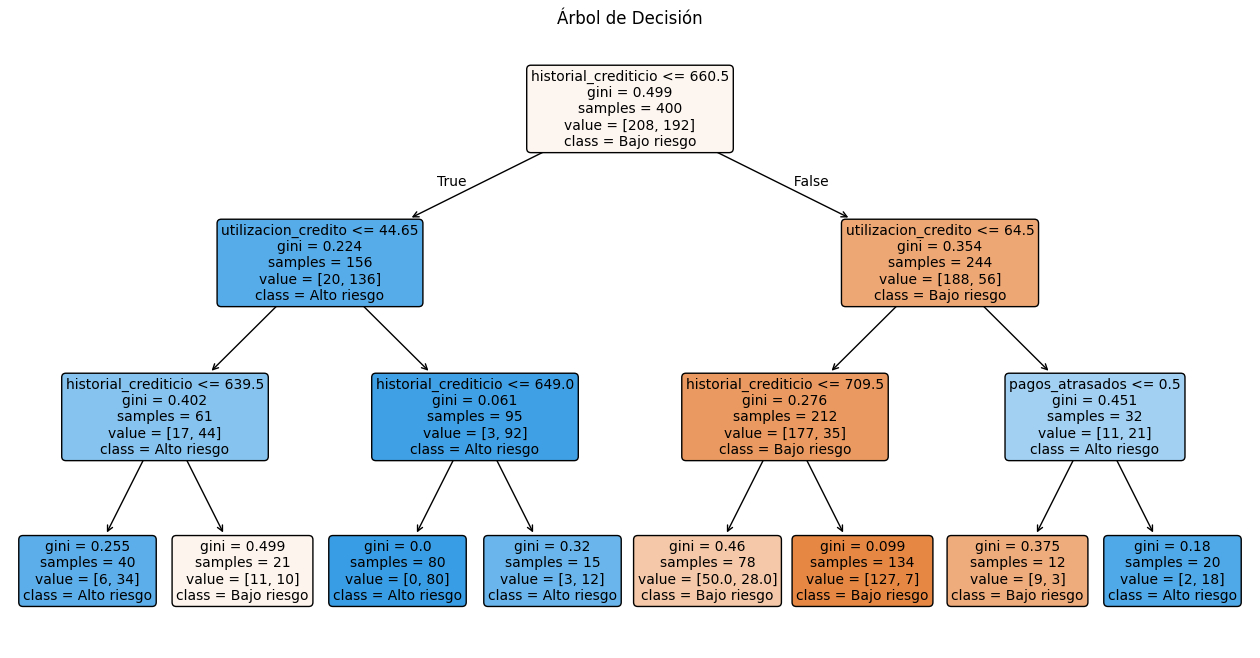

In [ ]:
#5.4
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt


# 1. Cargar datos
df = pd.read_csv('solicitudes_credito_500.csv')


# 2. Imputar valores faltantes
cols_faltantes = ['antiguedad_laboral', 'utilizacion_credito', 'pagos_atrasados']
for c in cols_faltantes:
    df[c] = df[c].fillna(df[c].median())


# 3. Variables de entrada (X) y salida (y)
features = ['edad', 'ingreso_mensual', 'antiguedad_laboral', 'historial_crediticio',
            'creditos_activos', 'utilizacion_credito', 'pagos_atrasados',
            'monto_solicitado', 'plazo_meses']
X = df[features]
y = df['riesgo']


# 4. Separar en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5. Construcción y entrenamiento del árbol (más simple: 3 niveles)
tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(X_train, y_train)

print("Modelo entrenado correctamente.")


# 6. Gráfica del árbol de decisión

plt.figure(figsize=(16, 8))
plot_tree(tree,
          feature_names=features,
          class_names=['Bajo riesgo', 'Alto riesgo'],
          filled=True,
          fontsize=10,
          rounded=True)
plt.title("Árbol de Decisión")
plt.show()

Tabla Q final:


,Rechazar,Revisar,Aprobar
Bajo riesgo,-3.0,1.0,10.0
Alto riesgo,8.0,1.0,-10.0


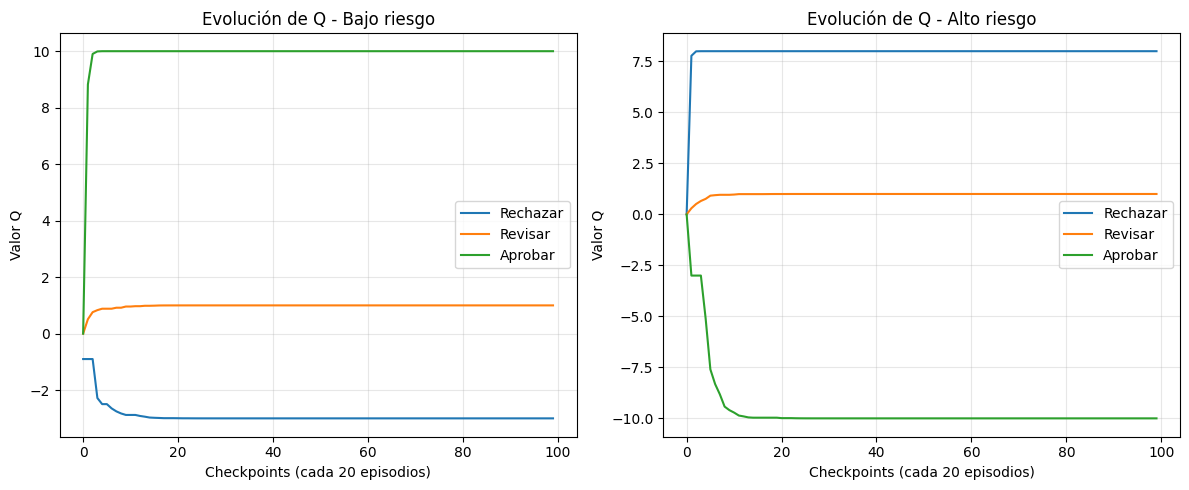

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


# Entrenamiento de la tabla Q (con registro del historial)

estados = ['Bajo riesgo', 'Alto riesgo']
acciones = ['Rechazar', 'Revisar', 'Aprobar']
Q = pd.DataFrame(0.0, index=estados, columns=acciones)

reward_table = {
    ('Bajo riesgo', 'Rechazar'): -3,
    ('Bajo riesgo', 'Revisar'): 1,
    ('Bajo riesgo', 'Aprobar'): 10,
    ('Alto riesgo', 'Rechazar'): 8,
    ('Alto riesgo', 'Revisar'): 1,
    ('Alto riesgo', 'Aprobar'): -10,
}

alpha = 0.3
epsilon = 0.3
n_episodios = 2000
rng = np.random.default_rng(42)

historial_Q = []  # aquí se guarda una "foto" de la tabla Q cada cierto número de episodios

for ep in range(n_episodios):
    estado = rng.choice(estados)
    if rng.random() < epsilon:
        accion = rng.choice(acciones)
    else:
        accion = Q.loc[estado].idxmax()
    r = reward_table[(estado, accion)]
    Q.loc[estado, accion] += alpha * (r - Q.loc[estado, accion])

    if ep % 20 == 0:               # guarda un checkpoint cada 20 episodios
        historial_Q.append(Q.copy())

print("Tabla Q final:")
display(Q.round(2))

# Gráfica de evolución de los valores Q

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, estado in enumerate(estados):
    for accion in acciones:
        valores = [h.loc[estado, accion] for h in historial_Q]
        axes[i].plot(valores, label=accion)
    axes[i].set_title(f"Evolución de Q - {estado}")
    axes[i].set_xlabel("Checkpoints (cada 20 episodios)")
    axes[i].set_ylabel("Valor Q")
    axes[i].legend()
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()